In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Hh18sFrYtzrGAbVkMeqg")
project = rf.workspace("atech-witjl").project("pedestrian-kmhf3")
version = project.version(3)
dataset = version.download("coco")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 115.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pedestrian-3 in coco:: 100%|██████████| 3963/3963 [00:02<00:00, 1755.23it/s]


In [7]:
import pandas as pd
import tensorflow as tf
import os
import torch
from pycocotools.coco import COCO
import json


BASE_PATH = "./pedestrian-3"
TRAIN_PATH = f"{BASE_PATH}/train"
TRAIN_ANN = os.path.join(TRAIN_PATH, "_annotations.coco.json")
VAL_PATH = f"{BASE_PATH}/valid"
VAL_ANN =  os.path.join(VAL_PATH, "_annotations.coco.json")
TEST_PATH = f"{BASE_PATH}/test"
TEST_ANN = os.path.join(TEST_PATH, "_annotations.coco.json")

# remove item id:0 from train annotations categories
with open(TRAIN_ANN, 'r') as f:
    train_data = json.load(f)
    train_data['categories'] = [cat for cat in train_data['categories'] if cat['id'] != 0]
with open(TRAIN_ANN, 'w') as f:
    json.dump(train_data, f)

with open(VAL_ANN, 'r') as f:
    train_data = json.load(f)
    train_data['categories'] = [cat for cat in train_data['categories'] if cat['id'] != 0]
with open(VAL_ANN, 'w') as f:
    json.dump(train_data, f)

with open(TEST_ANN, 'r') as f:
    train_data = json.load(f)
    train_data['categories'] = [cat for cat in train_data['categories'] if cat['id'] != 0]
with open(TEST_ANN, 'w') as f:
    json.dump(train_data, f)

# Load COCO annotations
coco = COCO(TRAIN_ANN)

# Get number of images
num_images = len(coco.imgs)
print(f"Number of images (Train): {num_images}")
num_classes = len(coco.cats)
print(f"Number of classes (Train): {num_classes}")
class_info = coco.loadCats(coco.getCatIds())
print("Classes:", [cat['name'] for cat in class_info])


# Some constants
IMG_SIZE = 256



loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Number of images (Train): 2756
Number of classes (Train): 3
Classes: ['Person_riding_bycycle', 'Person_riding_kickboard', 'Person_riding_motorcycle']


In [8]:
import os
import cv2
from PIL import Image
import torch
from torch.utils.data import Dataset
from pycocotools.coco import COCO


class COCODataset(Dataset):
    """COCO-style dataset usable from scripts and notebooks.

    Place this file next to your notebook and import with:
        from datasets import COCODataset

    The class returns (image_tensor, target_dict) where target_dict has keys
    expected by torchvision detection models: 'boxes', 'labels', 'image_id', 'area', 'iscrowd'.
    """

    def __init__(self, annotation_path, image_dir, transform=None, target_transform=None):
        self.coco = COCO(annotation_path)
        self.image_dir = image_dir
        self.transform = transform
        self.target_transform = target_transform
        self.ids = list(sorted(self.coco.imgs.keys()))

        # Category info
        self.categories = self.coco.loadCats(self.coco.getCatIds())
        self.classes = {cat['id']: cat['name'] for cat in self.categories}
        # Map original COCO category id -> contiguous index (0-based). We will return labels 1..N
        self.class_ids = {cat['id']: i for i, cat in enumerate(self.categories)}
        self.num_classes = len(self.categories)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):
        img_id = self.ids[index]
        img_info = self.coco.imgs[img_id]
        image_path = os.path.join(self.image_dir, img_info['file_name'])

        # Read with OpenCV, convert to RGB and to PIL so torchvision transforms behave consistently
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Image not found: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(image)

        orig_w, orig_h = pil_img.size

        # Load annotations and convert bbox format to [x1, y1, x2, y2]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        annotations = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        for ann in annotations:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])
            labels.append(self.class_ids[ann['category_id']] + 1)  # 1-based labels for torchvision

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        # Apply transforms (expecting a torchvision transform that returns a tensor)
        if self.transform:
            transformed = self.transform(pil_img)
        else:
            from torchvision.transforms import ToTensor
            transformed = ToTensor()(pil_img)

        # Determine new size
        if isinstance(transformed, torch.Tensor):
            _, new_h, new_w = transformed.shape
        else:
            new_w, new_h = transformed.size

        # Scale boxes from original to new coordinates
        if boxes.numel() > 0 and (orig_w != new_w or orig_h != new_h):
            sx = float(new_w) / float(orig_w)
            sy = float(new_h) / float(orig_h)
            boxes[:, 0] = boxes[:, 0] * sx
            boxes[:, 1] = boxes[:, 1] * sy
            boxes[:, 2] = boxes[:, 2] * sx
            boxes[:, 3] = boxes[:, 3] * sy

            # Clamp to image bounds
            boxes[:, 0].clamp_(0, new_w - 1)
            boxes[:, 1].clamp_(0, new_h - 1)
            boxes[:, 2].clamp_(0, new_w - 1)
            boxes[:, 3].clamp_(0, new_h - 1)

            widths = boxes[:, 2] - boxes[:, 0]
            heights = boxes[:, 3] - boxes[:, 1]
            keep = (widths > 1) & (heights > 1)
            if not keep.all():
                boxes = boxes[keep]
                labels = labels[keep]

        if boxes.numel() == 0:
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64)

        # Return image_id as a scalar tensor (0-d) to make .item() safe in callers
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor(img_id, dtype=torch.int64),
            'area': area,
            'iscrowd': iscrowd,
        }

        return transformed, target

    def get_class_names(self):
        return [cat['name'] for cat in self.categories]

    def get_class_mapping(self):
        return {i+1: cat['name'] for i, cat in enumerate(self.categories)}

In [9]:
from torch.utils.data import DataLoader, Subset
import numpy as np

def create_subset(dataset, subset_size=0.1, random_seed=42):
    """
    Create a random subset of the dataset

    Args:
        dataset: The full dataset
        subset_size: Either fraction (0.0-1.0) or absolute number of samples
        random_seed: Random seed for reproducibility
    """
    dataset_size = len(dataset)

    # Calculate actual subset size
    if isinstance(subset_size, float) and 0 < subset_size <= 1:
        subset_size = int(dataset_size * subset_size)
    elif isinstance(subset_size, int):
        subset_size = min(subset_size, dataset_size)
    else:
        raise ValueError("subset_size should be float (0-1) or int")

    # Set random seed for reproducibility
    np.random.seed(random_seed)

    # Create random indices
    indices = np.random.choice(dataset_size, subset_size, replace=False)

    # Create subset
    subset = Subset(dataset, indices)

    print(f"Created subset: {len(subset)}/{dataset_size} samples ({len(subset)/dataset_size*100:.1f}%)")
    return subset



In [10]:
def create_dataloaders(train_dataset, val_dataset, batch_size=8, num_workers=2):
    """
    Create training and validation dataloaders

    Args:
        train_dataset: Training dataset
        val_dataset: Validation dataset
        batch_size: Batch size for training
        num_workers: Number of workers for data loading
    """

    def collate_fn(batch):
        """
        Custom collate function for object detection
        Since each image can have different numbers of objects,
        we can't stack the targets like in classification
        """
        return tuple(zip(*batch))

    # Training DataLoader
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        collate_fn=collate_fn,
        pin_memory=False  # Faster GPU transfer
    )

    # Validation DataLoader
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,  # No shuffle for validation
        num_workers=num_workers,
        collate_fn=collate_fn,
        pin_memory=False
    )

    print(f"Training batches: {len(train_loader)}")
    print(f"Validation batches: {len(val_loader)}")

    return train_loader, val_loader

In [11]:
from torchvision.transforms import v2 as T2
import torch

# This should work with any torchvision version
train_transform = T2.Compose([
    T2.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T2.RandomHorizontalFlip(p=0.3),
    T2.ToTensor(),  # Works reliably
    T2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = T2.Compose([
    T2.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T2.ToTensor(),
    T2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Use with your dataset
train_dataset = COCODataset(
    annotation_path=TRAIN_ANN,
    image_dir=TRAIN_PATH,
    transform=train_transform
)

val_dataset = COCODataset(
    annotation_path=VAL_ANN,
    image_dir=VAL_PATH,
    transform=val_transform
)

BATCH_SIZE = 8
NUM_WORKERS = 0

# Create subsets (make sure to use the correct dataset for validation)
# Use safe min(...) so this cell won't error if datasets are smaller than the hardcoded numbers.
# train_subset_size = min(689, len(train_dataset))
# val_subset_size = min(189, len(val_dataset))

# train_subset = torch.utils.data.Subset(train_dataset, list(range(train_subset_size)))
# val_subset = torch.utils.data.Subset(val_dataset, list(range(val_subset_size)))

train_loader, val_loader = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

# print(f"Created train subset: {len(train_subset)} / {len(train_dataset)}")
# print(f"Created val subset:   {len(val_subset)} / {len(val_dataset)}")

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Training batches: 345
Validation batches: 100


The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.


In [12]:
def verify_dataset_transforms(dataset, dataset_name="Dataset", num_samples=3):
    """
    Verify that transforms are working correctly
    """
    print(f"\n{'='*50}")
    print(f"VERIFYING {dataset_name.upper()}")
    print(f"{'='*50}")

    for i in range(min(num_samples, len(dataset))):
        image, target = dataset[i]

        print(f"\n--- Sample {i} ---")

        # Check image properties
        print(f"Image shape: {image.shape}")  # Should be (3, IMG_SIZE, IMG_SIZE)
        print(f"Image dtype: {image.dtype}")  # Should be torch.float32
        print(f"Image range: [{image.min():.3f}, {image.max():.3f}]")  # Should be ~[-1, 1] after normalize

        # Check if image is properly resized
        expected_shape = (3, IMG_SIZE, IMG_SIZE)
        if image.shape == expected_shape:
            print("✅ Image correctly resized")
        else:
            print(f"❌ Image size incorrect. Expected {expected_shape}, got {image.shape}")

        # Check normalization
        if image.min() >= -1.0 and image.max() <= 1.0:
            print("✅ Normalization appears correct")
        else:
            print("❌ Normalization may be incorrect")

        # Check targets
        boxes = target['boxes']
        labels = target['labels']
        print(f"Number of objects: {len(boxes)}")

        if len(boxes) > 0:
            # Check if boxes are within image bounds
            box_within_bounds = True
            for box in boxes:
                x1, y1, x2, y2 = box
                if x1 < 0 or y1 < 0 or x2 > IMG_SIZE or y2 > IMG_SIZE:
                    box_within_bounds = False
                    break

            if box_within_bounds:
                print("✅ Bounding boxes within image bounds")
            else:
                print("❌ Some bounding boxes outside image bounds")

            # Print first box and label
            print(f"First box: {boxes[0].tolist()}")
            print(f"First label: {labels[0].item()}")

# Verify both datasets
verify_dataset_transforms(train_dataset, "TRAIN", num_samples=3)
verify_dataset_transforms(val_dataset, "VALIDATION", num_samples=2)



VERIFYING TRAIN

--- Sample 0 ---
Image shape: torch.Size([3, 256, 256])
Image dtype: torch.float32
Image range: [-1.000, 1.000]
✅ Image correctly resized
✅ Normalization appears correct
Number of objects: 1
✅ Bounding boxes within image bounds
First box: [92.80000305175781, 137.48147583007812, 109.4666748046875, 202.42962646484375]
First label: 2

--- Sample 1 ---
Image shape: torch.Size([3, 256, 256])
Image dtype: torch.float32
Image range: [-1.000, 1.000]
✅ Image correctly resized
✅ Normalization appears correct
Number of objects: 2
✅ Bounding boxes within image bounds
First box: [126.40000915527344, 29.629629135131836, 133.60000610351562, 63.051849365234375]
First label: 2

--- Sample 2 ---
Image shape: torch.Size([3, 256, 256])
Image dtype: torch.float32
Image range: [-0.984, 1.000]
✅ Image correctly resized
✅ Normalization appears correct
Number of objects: 1
✅ Bounding boxes within image bounds
First box: [161.73333740234375, 191.05184936523438, 188.8000030517578, 254.814804077


=== Plotting Single Detailed Example ===


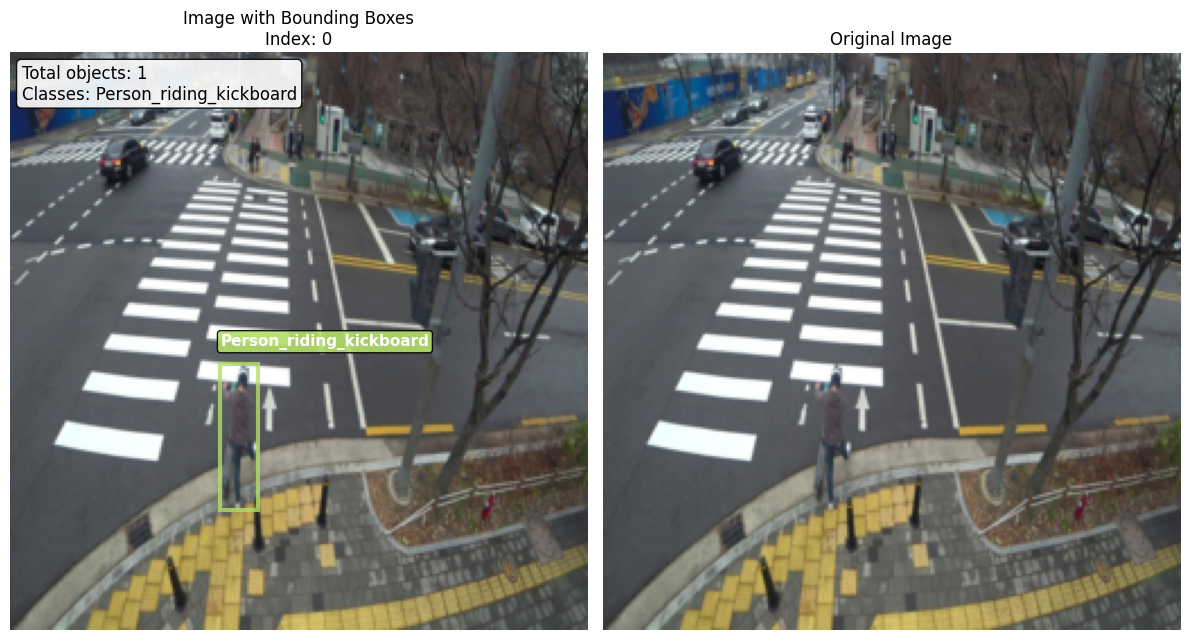

=== Detailed Information ===
Image Index: 0
Image Shape: torch.Size([3, 256, 256])
Number of objects: 1
Object details:
  1: Person_riding_kickboard at [92.8, 137.5, 109.5, 202.4]


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
import random

def denormalize(image, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]):
    """
    Denormalize a normalized image tensor for visualization
    """
    if torch.is_tensor(image):
        image = image.clone()
        for t, m, s in zip(image, mean, std):
            t.mul_(s).add_(m)  # Reverse normalization: (x * std) + mean
        image = image.clamp(0, 1)  # Clamp to [0, 1] range
        image = image.permute(1, 2, 0).numpy()  # CHW to HWC
    return image

def plot_single_example(dataset, index=None, figsize=(12, 8)):
    """
    Plot a single detailed example from the dataset
    """
    if index is None:
        index = random.randint(0, len(dataset) - 1)

    # Get sample
    image, target = dataset[index]

    # Denormalize image
    image_denorm = denormalize(image)

    # Get class names
    class_names = dataset.get_class_names()

    # Create plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Plot 1: Original image with bounding boxes
    ax1.imshow(image_denorm)
    ax1.set_title(f'Image with Bounding Boxes\nIndex: {index}')
    ax1.axis('off')

    # Plot 2: Just the image
    ax2.imshow(image_denorm)
    ax2.set_title('Original Image')
    ax2.axis('off')

    # Plot bounding boxes on first subplot
    boxes = target['boxes']
    labels = target['labels']

    colors = plt.cm.Set3(np.linspace(0, 1, len(class_names)))

    if len(boxes) > 0:
        for i, (box, label) in enumerate(zip(boxes, labels)):
            if torch.is_tensor(box):
                box = box.numpy()
            if torch.is_tensor(label):
                label = label.item()

            x1, y1, x2, y2 = box
            width = x2 - x1
            height = y2 - y1

            color = colors[(label - 1) % len(colors)]

            # Create rectangle
            rect = patches.Rectangle(
                (x1, y1), width, height,
                linewidth=3, edgecolor=color, facecolor='none', alpha=0.8
            )
            ax1.add_patch(rect)

            # Add label
            class_name = class_names[label - 1]
            ax1.text(
                x1, y1 - 8, f'{class_name}',
                fontsize=11, color='white', weight='bold',
                bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.9)
            )

    # Add statistics
    stats_text = f"Total objects: {len(boxes)}"
    if len(boxes) > 0:
        unique_labels = set([label.item() if torch.is_tensor(label) else label for label in labels])
        unique_class_names = [class_names[label-1] for label in unique_labels]
        stats_text += f"\nClasses: {', '.join(unique_class_names)}"

    ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

    plt.tight_layout()
    plt.show()

    # Print detailed info
    print(f"=== Detailed Information ===")
    print(f"Image Index: {index}")
    print(f"Image Shape: {image.shape}")
    print(f"Number of objects: {len(boxes)}")
    if len(boxes) > 0:
        print("Object details:")
        for i, (box, label) in enumerate(zip(boxes, labels)):
            if torch.is_tensor(label):
                label = label.item()
            class_name = class_names[label - 1]
            print(f"  {i+1}: {class_name} at [{box[0]:.1f}, {box[1]:.1f}, {box[2]:.1f}, {box[3]:.1f}]")

def plot_batch_examples(dataloader, num_batches=1):
    """
    Plot examples from dataloader batches
    """
    for batch_idx, (images, targets) in enumerate(dataloader):
        if batch_idx >= num_batches:
            break

        print(f"\n=== Batch {batch_idx + 1} ===")
        print(f"Number of images in batch: {len(images)}")

        # Plot each image in the batch
        for img_idx, (image, target) in enumerate(zip(images, targets)):
            if img_idx >= 4:  # Only plot first 4 images per batch
                break

            fig, ax = plt.subplots(1, 1, figsize=(8, 6))

            # Denormalize image
            image_denorm = denormalize(image)

            # Plot image
            ax.imshow(image_denorm)
            ax.set_title(f'Batch {batch_idx + 1}, Image {img_idx + 1}')
            ax.axis('off')

            # Plot bounding boxes
            boxes = target['boxes']
            labels = target['labels']

            if len(boxes) > 0:
                class_names = train_dataset.get_class_names()
                colors = plt.cm.Set3(np.linspace(0, 1, len(class_names)))

                for box, label in zip(boxes, labels):
                    if torch.is_tensor(box):
                        box = box.numpy()
                    if torch.is_tensor(label):
                        label = label.item()

                    x1, y1, x2, y2 = box
                    width = x2 - x1
                    height = y2 - y1

                    color = colors[(label - 1) % len(colors)]

                    rect = patches.Rectangle(
                        (x1, y1), width, height,
                        linewidth=2, edgecolor=color, facecolor='none'
                    )
                    ax.add_patch(rect)

                    class_name = class_names[label - 1]
                    ax.text(
                        x1, y1 - 5, class_name,
                        fontsize=9, color='white', weight='bold',
                        bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.8)
                    )

            plt.tight_layout()
            plt.show()

            print(f"  Image {img_idx + 1}: {len(boxes)} objects")

print("\n=== Plotting Single Detailed Example ===")
plot_single_example(train_dataset, index=0)  # Plot first image

In [14]:
import torch
import torch.nn as nn
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.ops import sigmoid_focal_loss

class RetinaNetDetector(nn.Module):
    def __init__(self, num_classes, pretrained_backbone=True, trainable_backbone_layers=3):
        super().__init__()

        # Create model with your custom number of classes
        # Use pretrained backbone but don't load the full pretrained model
        self.model = retinanet_resnet50_fpn(
            num_classes=num_classes,
            pretrained_backbone=pretrained_backbone,
            trainable_backbone_layers=trainable_backbone_layers
        )

    def forward(self, images, targets=None):
        return self.model(images, targets)

    def predict(self, images, confidence_threshold=0.5):
        """Convenience method for inference"""
        self.model.eval()
        with torch.no_grad():
            predictions = self.model(images)

        # Filter predictions by confidence
        filtered_predictions = []
        for pred in predictions:
            keep = pred['scores'] > confidence_threshold
            filtered_pred = {
                'boxes': pred['boxes'][keep],
                'labels': pred['labels'][keep],
                'scores': pred['scores'][keep]
            }
            filtered_predictions.append(filtered_pred)

        return filtered_predictions

In [15]:
import os
import glob
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR


def setup_training(model, train_loader, val_loader, device):
    """
    Setup complete training pipeline
    """
    # Move model to device
    model = model.to(device)

    # Optimizer
    optimizer = optim.AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )

    # Learning rate scheduler
    scheduler = StepLR(optimizer, step_size=10, gamma=0.1)

    return model, optimizer, scheduler


def save_checkpoint(model, optimizer, scheduler, epoch, checkpoint_dir='./checkpoints', prefix='retinanet'):
    """Save model + optimizer + scheduler state. Saves model_state_dict on CPU to avoid device issues."""
    os.makedirs(checkpoint_dir, exist_ok=True)
    # Move model state to cpu for safe saving
    model_state_cpu = {k: v.cpu() for k, v in model.state_dict().items()}
    state = {
        'epoch': epoch,
        'model_state_dict': model_state_cpu,
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
    }
    # save each epoch
    path = os.path.join(checkpoint_dir, f"{prefix}_epoch{epoch}.pth")
    # torch.save(state, path)

    # Also update a 'latest' symlink-like copy for convenience (overwrites)
    latest_path = os.path.join(checkpoint_dir, f"{prefix}_latest.pth")
    torch.save(state, latest_path)
    print(f"Saved checkpoint: {path}")
    print(f"Saved latest copy: {latest_path}")
    return path


def load_checkpoint(path, model, optimizer=None, scheduler=None, device=None):
    """Load checkpoint into model/optimizer/scheduler.

    Args:
      path: str path to checkpoint (.pth)
      model: nn.Module instance (already created)
      optimizer: optimizer instance or None
      scheduler: scheduler instance or None
      device: torch.device or string. If provided, checkpoint tensors will be mapped to this device.

    Returns:
      start_epoch: int - next epoch to begin (checkpoint_epoch + 1)
    """
    if device is None:
        device = torch.device('cpu')
    print(f"Loading checkpoint {path} to device {device}")
    checkpoint = torch.load(path, map_location=device)

    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    # Load optimizer state if provided
    if optimizer is not None and 'optimizer_state_dict' in checkpoint and checkpoint['optimizer_state_dict'] is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        # Move optimizer state tensors to device
        for state in optimizer.state.values():
            for k, v in list(state.items()):
                if isinstance(v, torch.Tensor):
                    state[k] = v.to(device)

    # Load scheduler state if provided
    if scheduler is not None and 'scheduler_state_dict' in checkpoint and checkpoint['scheduler_state_dict'] is not None:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    epoch = checkpoint.get('epoch', 0)
    start_epoch = int(epoch) + 1
    print(f"Checkpoint loaded. Resuming from epoch {start_epoch}")
    return start_epoch


def train_one_epoch(model, optimizer, train_loader, device, epoch):
    """
    Train for one epoch
    """
    model.train()
    total_loss = 0

    for batch_idx, (images, targets) in enumerate(train_loader):
        # Move data to device
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass - returns loss dict during training
        loss_dict = model(images, targets)

        # Calculate total loss
        losses = sum(loss for loss in loss_dict.values())

        # Backward pass
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

        if batch_idx % 20 == 0:
            # Some torchvision detection models return keys like 'classification' and 'bbox_regression'
            cls_loss = loss_dict.get('classification')
            reg_loss = loss_dict.get('bbox_regression')
            cls_str = f"Cls: {cls_loss.item():.4f}" if cls_loss is not None else ''
            reg_str = f"Reg: {reg_loss.item():.4f}" if reg_loss is not None else ''
            print(f'Epoch: {epoch} | Batch: {batch_idx}/{len(train_loader)} | Loss: {losses.item():.4f} | {cls_str} {reg_str}')

    avg_loss = total_loss / len(train_loader) if len(train_loader) > 0 else 0.0
    return avg_loss


def validate(model, val_loader, device):
    """
    Validate the model by computing loss on the validation set.

    Note: torchvision detection models return a dict of losses when the model is in train mode
    and targets are provided, but return detections (a list) in eval mode. To compute losses
    during validation we temporarily set the model to train mode while using torch.no_grad()
    to avoid gradient computations.
    """
    # Preserve original training state
    was_training = model.training
    # Ensure model returns loss dict
    model.train()

    total_loss = 0

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(val_loader):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_output = model(images, targets)

            # If model returned predictions (list) unexpectedly, skip batch
            if isinstance(loss_output, list):
                print(f"Warning: model returned predictions during validation for batch {batch_idx}; skipping batch loss computation.")
                continue

            losses = sum(loss for loss in loss_output.values())
            total_loss += losses.item()

    # Restore original training/eval state
    if not was_training:
        model.eval()

    avg_loss = total_loss / len(val_loader) if len(val_loader) > 0 else 0.0
    return avg_loss


def train_model(model, train_loader, val_loader, num_epochs=10, checkpoint_dir='./checkpoints', resume_from=None):
    """
    Complete training loop with checkpoint saving every epoch.

    If resume_from is provided (path to checkpoint), will load it and continue.
    """
    # Device selection: prefer MPS (macOS), then CUDA, then CPU
    device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
    print(f"Using device: {device}")

    # Setup training (moves model to device and returns optimizer/scheduler)
    model, optimizer, scheduler = setup_training(model, train_loader, val_loader, device)

    start_epoch = 1
    if resume_from is not None:
        start_epoch = load_checkpoint(resume_from, model, optimizer=optimizer, scheduler=scheduler, device=device)

    train_losses = []
    val_losses = []

    for epoch in range(start_epoch - 1, num_epochs):
        epoch_num = epoch + 1
        print(f"\nEpoch {epoch_num}/{num_epochs}")
        print("-" * 50)

        # Train
        train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch_num)
        train_losses.append(train_loss)

        # Validate
        val_loss = validate(model, val_loader, device)
        val_losses.append(val_loss)

        # Update learning rate
        if scheduler is not None:
            scheduler.step()

        print(f"Epoch {epoch_num} Summary:")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss: {val_loss:.4f}")
        print(f"  Learning Rate: {scheduler.get_last_lr()[0]:.2e}" if scheduler is not None else "  Learning Rate: N/A")

        # Save checkpoint for this epoch
        save_checkpoint(model, optimizer, scheduler, epoch_num, checkpoint_dir=checkpoint_dir, prefix='retinanet')

    return model, train_losses, val_losses

In [16]:
# Calculate number of classes (including background)
num_classes = len(train_dataset.get_class_names()) + 1  # +1 for background
print(f"Number of classes: {num_classes}")
print(f"Class names: {train_dataset.get_class_names()}")

# Create model - use the simple approach
model = RetinaNetDetector(
    num_classes=num_classes,
    pretrained_backbone=True  # Use pretrained backbone but custom head
)

# Check model structure
print("\nModel structure:")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Number of trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Number of classes: 4
Class names: ['Person_riding_bycycle', 'Person_riding_kickboard', 'Person_riding_motorcycle']


The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please use 'weights_backbone' instead.
Arguments other than a weight enum or `None` for 'weights_backbone' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights_backbone=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights_backbone=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.



Model structure:
Number of parameters: 32,210,184
Number of trainable parameters: 31,987,784


In [17]:
from torchvision.transforms import v2 as T2
import torch

# This should work with any torchvision version
IMG_SIZE = 512 # Modified IMG_SIZE to 512

train_transform = T2.Compose([
    T2.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T2.RandomCrop(size=(IMG_SIZE, IMG_SIZE)), # Added RandomCrop
    T2.RandomHorizontalFlip(p=0.3),
    T2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Added ColorJitter
    T2.RandomAdjustSharpness(sharpness_factor=2, p=0.5), # Added RandomAdjustSharpness
    T2.RandomAutocontrast(p=0.5), # Added RandomAutocontrast
    T2.Compose([T2.ToImage(), T2.ToDtype(torch.float32, scale=True)]), # Replaced ToTensor()
    T2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = T2.Compose([
    T2.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T2.Compose([T2.ToImage(), T2.ToDtype(torch.float32, scale=True)]),
    T2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Use with your dataset
train_dataset = COCODataset(
    annotation_path=TRAIN_ANN,
    image_dir=TRAIN_PATH,
    transform=train_transform
)

val_dataset = COCODataset(
    annotation_path=VAL_ANN,
    image_dir=VAL_PATH,
    transform=val_transform
)

BATCH_SIZE = 8
NUM_WORKERS = 0

# Create subsets (make sure to use the correct dataset for validation)
# Use safe min(...) so this cell won't error if datasets are smaller than the hardcoded numbers.
# train_subset_size = min(689, len(train_dataset))
# val_subset_size = min(189, len(val_dataset))

# train_subset = torch.utils.data.Subset(train_dataset, list(range(train_subset_size)))
# val_subset = torch.utils.data.Subset(val_dataset, list(range(val_subset_size)))

train_loader, val_loader = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

# print(f"Created train subset: {len(train_subset)} / {len(train_dataset)}")
# print(f"Created val subset:   {len(val_subset)} / {len(val_dataset)}")

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Training batches: 345
Validation batches: 100


In [18]:
import torch
import torch.optim as optim

# Choose device: prefer MPS if available on macOS, otherwise fall back
device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"Using device: {device}")

# Move model to device
model.to(device)

# Create optimizer after moving model to device (recommended)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=15,
    checkpoint_dir='./checkpoints'
)

Using device: cuda
Using device: cuda

Epoch 1/15
--------------------------------------------------
Epoch: 1 | Batch: 0/345 | Loss: 1.8920 | Cls: 1.1636 Reg: 0.7284
Epoch: 1 | Batch: 20/345 | Loss: 1.7687 | Cls: 1.0697 Reg: 0.6990
Epoch: 1 | Batch: 40/345 | Loss: 1.5471 | Cls: 1.0126 Reg: 0.5346
Epoch: 1 | Batch: 60/345 | Loss: 1.6875 | Cls: 1.0135 Reg: 0.6740
Epoch: 1 | Batch: 80/345 | Loss: 1.5080 | Cls: 0.8903 Reg: 0.6177
Epoch: 1 | Batch: 100/345 | Loss: 1.5660 | Cls: 0.8887 Reg: 0.6773
Epoch: 1 | Batch: 120/345 | Loss: 1.3441 | Cls: 0.7664 Reg: 0.5778
Epoch: 1 | Batch: 140/345 | Loss: 1.2358 | Cls: 0.7452 Reg: 0.4907
Epoch: 1 | Batch: 160/345 | Loss: 1.6474 | Cls: 1.1525 Reg: 0.4950
Epoch: 1 | Batch: 180/345 | Loss: 1.2416 | Cls: 0.7562 Reg: 0.4854
Epoch: 1 | Batch: 200/345 | Loss: 1.2738 | Cls: 0.7242 Reg: 0.5496
Epoch: 1 | Batch: 220/345 | Loss: 1.3647 | Cls: 0.8027 Reg: 0.5620
Epoch: 1 | Batch: 240/345 | Loss: 1.2936 | Cls: 0.7500 Reg: 0.5437
Epoch: 1 | Batch: 260/345 | Loss: 

(RetinaNetDetector(
   (model): RetinaNet(
     (backbone): BackboneWithFPN(
       (body): IntermediateLayerGetter(
         (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
         (bn1): FrozenBatchNorm2d(64, eps=1e-05)
         (relu): ReLU(inplace=True)
         (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
         (layer1): Sequential(
           (0): Bottleneck(
             (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
             (bn1): FrozenBatchNorm2d(64, eps=1e-05)
             (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
             (bn2): FrozenBatchNorm2d(64, eps=1e-05)
             (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
             (bn3): FrozenBatchNorm2d(256, eps=1e-05)
             (relu): ReLU(inplace=True)
             (downsample): Sequential(
               (0): Conv2d(64, 256, kerne

In [19]:
import json
import torch
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

def _convert_outputs_to_coco_fmt_rescaled(outputs, image_ids, dataset, det_space_wh=(IMG_SIZE, IMG_SIZE), contig_to_orig=None, score_threshold=0.0):
    """
    Convert model outputs to COCO detection results format, rescaling boxes from detection space to original image sizes.
    - outputs: list[dict] with keys 'boxes','labels','scores' (boxes in XYXY in detection-space)
    - image_ids: list[int] image ids matching outputs
    - dataset: dataset instance providing dataset.coco and img sizes
    - det_space_wh: (width,height) of the model/detection coordinate space (IMG_SIZE, IMG_SIZE)
    - contig_to_orig: mapping label -> original COCO category id (optional)
    """
    results = []
    det_w, det_h = det_space_wh
    # pre-load image sizes map for speed
    coco = dataset.coco
    img_sizes = {img['id']: (img['width'], img['height']) for img in coco.loadImgs(coco.getImgIds())}
    for output, image_id in zip(outputs, image_ids):
        if output is None or image_id is None:
            continue
        boxes = output.get('boxes')
        scores = output.get('scores')
        labels = output.get('labels')
        if boxes is None or scores is None or labels is None:
            continue
        # cpu numpy
        boxes = boxes.detach().cpu().numpy()
        scores = scores.detach().cpu().numpy()
        labels = labels.detach().cpu().numpy()

        if image_id not in img_sizes:
            # skip if image id not found in GT (diagnostic caller will warn)
            continue
        orig_w, orig_h = img_sizes[image_id]
        sx = float(orig_w) / float(det_w)
        sy = float(orig_h) / float(det_h)

        for box, score, label in zip(boxes, scores, labels):
            if score < score_threshold:
                continue
            # box is [x1,y1,x2,y2] in detection space
            x1, y1, x2, y2 = box.tolist()
            w = x2 - x1
            h = y2 - y1
            # rescale coordinates to original image space
            rx = x1 * sx
            ry = y1 * sy
            rw = w * sx
            rh = h * sy
            # clamp to image bounds
            if rx < 0: rx = 0.0
            if ry < 0: ry = 0.0
            if rx + rw > orig_w: rw = max(0.0, orig_w - rx)
            if ry + rh > orig_h: rh = max(0.0, orig_h - ry)

            coco_label = int(label)
            if contig_to_orig is not None:
                coco_label = int(contig_to_orig.get(int(label), int(label)))

            result = {
                'image_id': int(image_id),
                'category_id': int(coco_label),
                'bbox': [float(rx), float(ry), float(rw), float(rh)],
                'score': float(score)
            }
            results.append(result)
    return results


def evaluate_coco_map(model, data_loader, dataset, device=None, iou_type='bbox', max_images=None, score_threshold=0.0, det_space_wh=(IMG_SIZE,IMG_SIZE), print_diagnostics=True):
    """
    Replacement evaluate function that rescales outputs from model/detection space (det_space_wh, e.g. (256,256))
    back to the original image sizes before creating COCO results.
    Returns the same stats dict structure as the earlier helper.
    """
    import torch
    from pycocotools.coco import COCO
    from pycocotools.cocoeval import COCOeval
    if device is None:
        device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))

    # Ensure the model is on the correct device and in evaluation mode
    model.to(device)
    model.eval()

    # Build contig->orig mapping: dataset.class_ids is {orig_id: idx0}
    contig_to_orig = None
    if hasattr(dataset, 'class_ids') and isinstance(dataset.class_ids, dict):
        contig_to_orig = {idx + 1: orig_id for orig_id, idx in dataset.class_ids.items()}

    coco_gt = getattr(dataset, 'coco', None)
    if coco_gt is None or not isinstance(coco_gt, COCO):
        raise ValueError('dataset must provide a .coco (pycocotools.COCO) object')

    all_results = []
    image_ids = []
    processed = 0

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(data_loader):
            imgs = [img.to(device) for img in images]
            outputs = model(imgs)
            # collect image ids robustly
            batch_image_ids = []
            if isinstance(targets, (list, tuple)):
                for t in targets:
                    iid = t.get('image_id')
                    if torch.is_tensor(iid):
                        try:
                            iid_val = int(iid.item())
                        except Exception:
                            try:
                                iid_val = int(iid.view(-1)[0].item())
                            except Exception:
                                iid_val = None
                    else:
                        try:
                            iid_val = int(iid)
                        except Exception:
                            iid_val = None
                    batch_image_ids.append(iid_val)
            else:
                batch_image_ids = [None] * len(outputs)

            if print_diagnostics and batch_idx == 0:
                print('First-batch target image_id samples:', batch_image_ids[:8])

            # Convert & rescale outputs
            batch_results = _convert_outputs_to_coco_fmt_rescaled(outputs, batch_image_ids, dataset, det_space_wh=det_space_wh, contig_to_orig=contig_to_orig, score_threshold=score_threshold)
            all_results.extend(batch_results)
            image_ids.extend(batch_image_ids)

            processed += len(batch_image_ids)
            if max_images is not None and processed >= max_images:
                break

    if len(all_results) == 0:
        if print_diagnostics:
            print('No detections to evaluate.')
        return None

    # Diagnostics: overlap between detected image_ids and GT
    if print_diagnostics:
        det_image_ids = set(r['image_id'] for r in all_results)
        gt_image_ids = set(coco_gt.getImgIds())
        overlap = det_image_ids & gt_image_ids
        print(f"Diagnostic: unique detection image_ids: {len(det_image_ids)}, GT image_ids: {len(gt_image_ids)}, overlap: {len(overlap)}")
        if len(overlap) == 0:
            print('WARNING: No overlap between detection image_ids and GT image_ids. COCOeval will return zeros.')
            print('Sample detected image_ids (first 10):', sorted(list(det_image_ids))[:10])
            print('Sample GT image_ids (first 10):', sorted(list(gt_image_ids))[:10])

    # Run pycocotools
    coco_dt = coco_gt.loadRes(all_results)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType=iou_type)

    valid_img_ids = [i for i in image_ids if i is not None]
    if len(valid_img_ids) == 0:
        valid_img_ids = list(coco_gt.getImgIds())
    coco_eval.params.imgIds = valid_img_ids

    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    stat_names = [
        'AP', 'AP50', 'AP75', 'AP_small', 'AP_medium', 'AP_large',
        'AR1', 'AR10', 'AR100', 'AR_small', 'AR_medium', 'AR_large'
    ]
    stats = {name: float(val) for name, val in zip(stat_names, coco_eval.stats.tolist())}
    stats['coco_eval'] = coco_eval
    stats['detections'] = all_results
    return stats

# Quick COCO-eval diagnostic run
# Recreate dataloaders (ensure they match current datasets and subsets)
train_loader, val_loader = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

# Device selection
device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"Running COCO eval diagnostics on device: {device}")

# Run evaluation on the full validation dataset
stats = evaluate_coco_map(
    model.model if hasattr(model, 'model') else model,
    val_loader,
    val_dataset,
    device=device,
    score_threshold=0.01,
    print_diagnostics=True
)

if stats is None:
    print('No detections were produced (stats is None).')
else:
    print('\nSummary stats:')
    for k, v in stats.items():
        if k in ('coco_eval', 'detections'):
            continue
        print(f"  {k}: {v:.4f}")

    dets = stats.get('detections', [])
    print(f"Total detections written: {len(dets)}")
    if len(dets) > 0:
        # show a few sample detections
        print('\nSample detections (first 5):')
        for d in dets[:5]:
            print(d)

# Next checks if AP==0:
#  - Confirm that image ids in detections overlap with dataset.coco image ids
if stats is not None:
    det_image_ids = set(d['image_id'] for d in stats['detections'])
    gt_image_ids = set(val_dataset.coco.getImgIds())
    overlap = det_image_ids & gt_image_ids
    print(f"\nUnique detection image_ids: {len(det_image_ids)}")
    print(f"Unique GT image_ids in val_dataset: {len(gt_image_ids)}")
    print(f"Overlap between detection and GT image_ids: {len(overlap)}")
    if len(overlap) == 0:
        print('WARNING: No overlap between detection image_ids and GT image_ids. This causes COCOeval to report zeros.')
        print('Possible causes: you evaluated on a Subset created from a different dataset, or image_id values differ (check dataset.image_id mapping).')


Training batches: 345
Validation batches: 100
Running COCO eval diagnostics on device: cuda
First-batch target image_id samples: [0, 1, 2, 3, 4, 5, 6, 7]
Diagnostic: unique detection image_ids: 794, GT image_ids: 796, overlap: 794
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.70s).
Accumulating evaluation results...
DONE (t=0.18s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.678
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.915
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.799
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.183
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.564
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.743
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.5

In [20]:
# Prediction + visualization helpers
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def predict_images(model, images, device=None, score_threshold=0.05, topk=5):
    """Run model inference on a list of image tensors and return filtered predictions on CPU."""
    # Accept model wrapper objects that store actual detector as `model.model`
    detector = model.model if hasattr(model, 'model') else model
    if device is None:
        device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
    detector.to(device)
    detector.eval()

    with torch.no_grad():
        imgs = [img.to(device) for img in images]
        outputs = detector(imgs)

    # Post-process and move to cpu
    results = []
    for out in outputs:
        # out is dict with keys 'boxes','labels','scores'
        boxes = out.get('boxes')
        labels = out.get('labels')
        scores = out.get('scores')
        if boxes is None or scores is None or labels is None:
            results.append({'boxes': torch.empty((0,4)), 'labels': torch.empty((0,), dtype=torch.long), 'scores': torch.empty((0,))})
            continue

        # Move to CPU for easier handling
        boxes = boxes.cpu()
        labels = labels.cpu()
        scores = scores.cpu()

        # Threshold
        keep_mask = scores >= float(score_threshold)
        if keep_mask.numel() == 0:
            results.append({'boxes': torch.empty((0,4)), 'labels': torch.empty((0,), dtype=torch.long), 'scores': torch.empty((0,))})
            continue
        keep_idx = torch.where(keep_mask)[0]

        # If topk requested, sort by score and take topk
        if topk is not None and keep_idx.numel() > 0:
            kept_scores = scores[keep_idx]
            sorted_idx = torch.argsort(kept_scores, descending=True)
            take = sorted_idx[:int(topk)]
            keep_idx = keep_idx[take]

        boxes = boxes[keep_idx]
        labels = labels[keep_idx]
        scores = scores[keep_idx]

        results.append({'boxes': boxes, 'labels': labels, 'scores': scores})

    return results


def visualize_prediction(dataset, index, model, device=None, score_threshold=0.05, topk=5, figsize=(10,10), show_gt=True):
    """Visualize a single dataset sample (by index) with model predictions overlaid.
    - dataset: your COCODataset instance (must return transformed image, target)
    - index: integer index into dataset
    - model: detector or wrapper (e.g. RetinaNetDetector)
    """
    # Retrieve sample from dataset (returns transformed tensors)
    image, target = dataset[index]

    # ensure device
    if device is None:
        device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))

    # Run prediction on the single image (model expects list of images)
    preds = predict_images(model, [image], device=device, score_threshold=score_threshold, topk=topk)[0]

    # Denormalize image if denormalize helper exists; else attempt simple conversion
    try:
        img_disp = denormalize(image)  # expects CHW tensor normalized as in notebook
    except Exception:
        img_disp = image.permute(1,2,0).cpu().numpy()
        img_disp = np.clip(img_disp, 0, 1)

    fig, ax = plt.subplots(1,1, figsize=figsize)
    ax.imshow(img_disp)
    ax.axis('off')

    # Plot predicted boxes
    for i in range(len(preds['boxes'])):
        box = preds['boxes'][i].numpy()
        score = float(preds['scores'][i].item())
        label = int(preds['labels'][i].item()) if preds['labels'].numel() > 0 else None
        x1, y1, x2, y2 = box.tolist()
        w = x2 - x1; h = y2 - y1
        rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='red', facecolor='none', alpha=0.9)
        ax.add_patch(rect)
        label_name = dataset.get_class_names()[label-1] if (label is not None and label-1 < len(dataset.get_class_names())) else str(label)
        ax.text(x1, max(0,y1-8), f'{label_name} {score:.2f}', color='white', fontsize=10, weight='bold', bbox=dict(facecolor='red', alpha=0.7))

    # Optionally plot GT boxes
    if show_gt and target is not None and 'boxes' in target and len(target['boxes']) > 0:
        gt_boxes = target['boxes']
        gt_labels = target.get('labels', None)
        for j in range(len(gt_boxes)):
            gb = gt_boxes[j].cpu().numpy() if torch.is_tensor(gt_boxes[j]) else np.array(gt_boxes[j])
            x1, y1, x2, y2 = gb.tolist()
            w = x2 - x1; h = y2 - y1
            rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='lime', facecolor='none', alpha=0.7)
            ax.add_patch(rect)
            if gt_labels is not None:
                g_label = int(gt_labels[j].item()) if torch.is_tensor(gt_labels[j]) else int(gt_labels[j])
                g_name = dataset.get_class_names()[g_label - 1] if (g_label - 1) < len(dataset.get_class_names()) else str(g_label)
                ax.text(x1, y1 + h + 4, f'GT: {g_name}', color='white', fontsize=9, bbox=dict(facecolor='green', alpha=0.7))

    plt.tight_layout()
    plt.show()


def visualize_batch_predictions(dataloader, model, device=None, score_threshold=0.05, topk=5, num_images=4, figsize=(12,8)):
    """Visualize predictions for a small number of images from a dataloader.
    Shows up to `num_images` images from the first batch(s)."""
    if device is None:
        device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))

    shown = 0
    for batch_idx, (images, targets) in enumerate(dataloader):
        # images is a tuple/list of tensors in our collate_fn
        for img_idx, image in enumerate(images):
            if shown >= num_images:
                return
            # Visualize - we need dataset for class names; try to find it from dataloader.dataset if present
            ds = getattr(dataloader, 'dataset', None)
            if ds is None and hasattr(dataloader, 'dataset'):
                ds = dataloader.dataset
            try:
                # visualize_prediction expects (dataset, index, model) so call fallback path below instead
                visualize_prediction(ds, img_idx, model, device=device, score_threshold=score_threshold, topk=topk, figsize=figsize)
            except Exception:
                # Fallback: directly call predict + plot on this image tensor
                try:
                    preds = predict_images(model, [image], device=device, score_threshold=score_threshold, topk=topk)[0]
                    try:
                        img_disp = denormalize(image)
                    except Exception:
                        img_disp = image.permute(1,2,0).cpu().numpy()
                        img_disp = np.clip(img_disp, 0, 1)
                    fig, ax = plt.subplots(1,1, figsize=figsize)
                    ax.imshow(img_disp)
                    ax.axis('off')
                    for i in range(len(preds['boxes'])):
                        box = preds['boxes'][i].numpy()
                        score = float(preds['scores'][i].item())
                        label = int(preds['labels'][i].item()) if preds['labels'].numel() > 0 else None
                        x1, y1, x2, y2 = box.tolist()
                        w = x2 - x1; h = y2 - y1
                        rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='red', facecolor='none', alpha=0.9)
                        ax.add_patch(rect)
                        label_name = ds.get_class_names()[label-1] if (ds is not None and label is not None and label-1 < len(ds.get_class_names())) else str(label)
                        ax.text(x1, max(0,y1-8), f'{label_name} {score:.2f}', color='white', fontsize=9, bbox=dict(facecolor='red', alpha=0.7))
                    plt.tight_layout()
                    plt.show()
                except Exception as e:
                    print('Failed to visualize batch image:', e)

            shown += 1
            if shown >= num_images:
                return


In [25]:
to_save = model.model if hasattr(model, "model") else model
torch.save(to_save.state_dict(), '/content/drive/MyDrive/Colab Notebooks/SIT/CV/model.pth')

In [ ]:
import torch.optim as optim
import os

# Device selection: prefer MPS (macOS), then CUDA, then CPU
device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"Using device for checkpoint loading: {device}")

# Initialize optimizer and scheduler for the model on the correct device
# This is necessary because load_checkpoint expects these objects
# Note: model should already be defined from previous steps
model, optimizer, scheduler = setup_training(model, train_loader, val_loader, device)

# Define the path to the latest checkpoint
latest_checkpoint_path = os.path.join('./checkpoints', 'retinanet_latest.pth')

# Load the checkpoint
# The return value (start_epoch) is not used here as we are only loading for evaluation
_ = load_checkpoint(latest_checkpoint_path, model, optimizer=optimizer, scheduler=scheduler, device=device)

print("Model weights loaded successfully from latest checkpoint.")

Using device for checkpoint loading: cuda
Loading checkpoint ./checkpoints/retinanet_latest.pth to device cuda
Checkpoint loaded. Resuming from epoch 16
Model weights loaded successfully from latest checkpoint.


In [ ]:
import torch
import torch.optim as optim

# Choose device: prefer MPS if available on macOS, otherwise fall back
device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"Using device: {device}")

# Move model to device
model.to(device)

# Create optimizer after moving model to device (recommended)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# Capture the return values of train_model
model, train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=15,
    checkpoint_dir='./checkpoints'
)

# Print confirmation that losses are captured
print(f"Captured train_losses for {len(train_losses)} epochs.")
print(f"Captured val_losses for {len(val_losses)} epochs.")

Using device: cuda
Using device: cuda

Epoch 1/15
--------------------------------------------------
Epoch: 1 | Batch: 0/345 | Loss: 0.2252 | Cls: 0.0903 Reg: 0.1350
Epoch: 1 | Batch: 20/345 | Loss: 0.4478 | Cls: 0.2552 Reg: 0.1926
Epoch: 1 | Batch: 40/345 | Loss: 0.6856 | Cls: 0.4181 Reg: 0.2676
Epoch: 1 | Batch: 60/345 | Loss: 0.6750 | Cls: 0.3618 Reg: 0.3132
Epoch: 1 | Batch: 80/345 | Loss: 0.5550 | Cls: 0.2996 Reg: 0.2554
Epoch: 1 | Batch: 100/345 | Loss: 0.1977 | Cls: 0.0730 Reg: 0.1247
Epoch: 1 | Batch: 120/345 | Loss: 0.6985 | Cls: 0.3971 Reg: 0.3014
Epoch: 1 | Batch: 140/345 | Loss: 0.4891 | Cls: 0.2629 Reg: 0.2262
Epoch: 1 | Batch: 160/345 | Loss: 0.5199 | Cls: 0.3222 Reg: 0.1978
Epoch: 1 | Batch: 180/345 | Loss: 0.7974 | Cls: 0.4627 Reg: 0.3347
Epoch: 1 | Batch: 200/345 | Loss: 0.2881 | Cls: 0.1320 Reg: 0.1562
Epoch: 1 | Batch: 220/345 | Loss: 0.4168 | Cls: 0.2424 Reg: 0.1744
Epoch: 1 | Batch: 240/345 | Loss: 0.2801 | Cls: 0.1239 Reg: 0.1561
Epoch: 1 | Batch: 260/345 | Loss: 

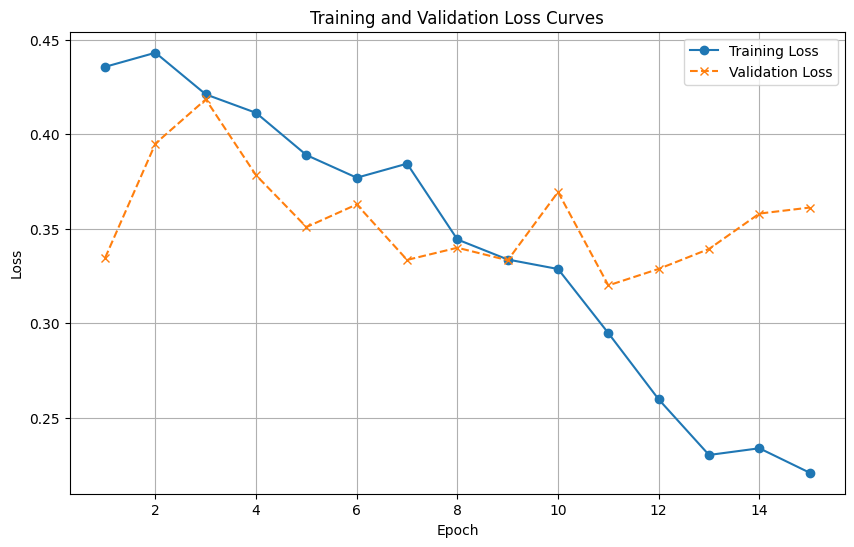

In [ ]:
import matplotlib.pyplot as plt

# Create a figure for the plot
plt.figure(figsize=(10, 6))

# Plot training loss
epochs = range(1, len(train_losses) + 1)
plt.plot(epochs, train_losses, label='Training Loss', marker='o', linestyle='-')

# Plot validation loss
plt.plot(epochs, val_losses, label='Validation Loss', marker='x', linestyle='--')

# Add labels, title, legend, and grid
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
print("Visualizing predictions for validation image at index 0:")
visualize_prediction(val_dataset, index=0, model=model)

print("\nVisualizing predictions for validation image at index 1:")
visualize_prediction(val_dataset, index=1, model=model)

Output hidden; open in https://colab.research.google.com to view.

# Further Hyperparameter Tuning


In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR

def setup_training(model, train_loader, val_loader, device, lr=1e-4, optimizer_type='AdamW', scheduler_config=None):
    """
    Setup complete training pipeline with configurable optimizer and scheduler.
    """
    model = model.to(device)

    # Optimizer selection
    if optimizer_type == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    elif optimizer_type == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    else:
        raise ValueError(f"Unsupported optimizer type: {optimizer_type}")

    # Learning rate scheduler selection
    scheduler = None
    if scheduler_config:
        if scheduler_config['type'] == 'StepLR':
            scheduler = StepLR(optimizer, step_size=scheduler_config.get('step_size', 10), gamma=scheduler_config.get('gamma', 0.1))
        elif scheduler_config['type'] == 'CosineAnnealingLR':
            # T_max is usually the number of training iterations or epochs
            scheduler = CosineAnnealingLR(optimizer, T_max=scheduler_config.get('T_max', 15))
        else:
            raise ValueError(f"Unsupported scheduler type: {scheduler_config['type']}")

    return model, optimizer, scheduler


def train_model(model, train_loader, val_loader, num_epochs=10, checkpoint_dir='./checkpoints', resume_from=None, lr=1e-4, optimizer_type='AdamW', scheduler_config=None):
    """
    Complete training loop with checkpoint saving every epoch.
    Now accepts lr, optimizer_type, and scheduler_config.
    """
    device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
    print(f"Using device: {device}")

    model, optimizer, scheduler = setup_training(model, train_loader, val_loader, device, lr=lr, optimizer_type=optimizer_type, scheduler_config=scheduler_config)

    start_epoch = 1
    if resume_from is not None:
        start_epoch = load_checkpoint(resume_from, model, optimizer=optimizer, scheduler=scheduler, device=device)

    train_losses = []
    val_losses = []

    for epoch in range(start_epoch - 1, num_epochs):
        epoch_num = epoch + 1
        print(f"\nEpoch {epoch_num}/{num_epochs}")
        print("-" * 50)

        train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch_num)
        train_losses.append(train_loss)

        val_loss = validate(model, val_loader, device)
        val_losses.append(val_loss)

        if scheduler is not None:
            scheduler.step()

        print(f"Epoch {epoch_num} Summary:")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss: {val_loss:.4f}")
        print(f"  Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")

        save_checkpoint(model, optimizer, scheduler, epoch_num, checkpoint_dir=checkpoint_dir, prefix='retinanet')

    return model, train_losses, val_losses

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR

# Re-initialize the model to ensure a clean start for a new training run
model = RetinaNetDetector(
    num_classes=num_classes,
    pretrained_backbone=True
)

# Experiment 1: AdamW optimizer, different LR, and CosineAnnealingLR scheduler
experiment1_lr = 5e-5 # Lower initial learning rate
experiment1_optimizer_type = 'AdamW'
experiment1_scheduler_config = {
    'type': 'CosineAnnealingLR',
    'T_max': 20 # Max epochs for cosine annealing
}
experiment1_num_epochs = 20 # Increased number of epochs for this experiment

print(f"\n--- Running Experiment 1 ---")
print(f"LR: {experiment1_lr}, Optimizer: {experiment1_optimizer_type}, Scheduler: {experiment1_scheduler_config['type']}")

# Train the model with new hyperparameters
model_exp1, train_losses_exp1, val_losses_exp1 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=experiment1_num_epochs,
    checkpoint_dir='./checkpoints/exp1',
    lr=experiment1_lr,
    optimizer_type=experiment1_optimizer_type,
    scheduler_config=experiment1_scheduler_config
)

print(f"Captured train_losses for {len(train_losses_exp1)} epochs.")
print(f"Captured val_losses for {len(val_losses_exp1)} epochs.")

The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please use 'weights_backbone' instead.
Arguments other than a weight enum or `None` for 'weights_backbone' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights_backbone=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights_backbone=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.



--- Running Experiment 1 ---
LR: 5e-05, Optimizer: AdamW, Scheduler: CosineAnnealingLR
Using device: cuda

Epoch 1/20
--------------------------------------------------
Epoch: 1 | Batch: 0/345 | Loss: 1.9392 | Cls: 1.1532 Reg: 0.7859
Epoch: 1 | Batch: 20/345 | Loss: 1.4076 | Cls: 0.7807 Reg: 0.6269
Epoch: 1 | Batch: 40/345 | Loss: 1.4563 | Cls: 0.8639 Reg: 0.5924
Epoch: 1 | Batch: 60/345 | Loss: 1.4135 | Cls: 0.8689 Reg: 0.5446
Epoch: 1 | Batch: 80/345 | Loss: 1.3638 | Cls: 0.8263 Reg: 0.5375
Epoch: 1 | Batch: 100/345 | Loss: 1.6288 | Cls: 1.0019 Reg: 0.6269
Epoch: 1 | Batch: 120/345 | Loss: 1.3101 | Cls: 0.7760 Reg: 0.5341
Epoch: 1 | Batch: 140/345 | Loss: 1.3468 | Cls: 0.8035 Reg: 0.5433
Epoch: 1 | Batch: 160/345 | Loss: 1.3287 | Cls: 0.8407 Reg: 0.4880
Epoch: 1 | Batch: 180/345 | Loss: 1.1288 | Cls: 0.6582 Reg: 0.4706
Epoch: 1 | Batch: 200/345 | Loss: 1.1562 | Cls: 0.6868 Reg: 0.4695
Epoch: 1 | Batch: 220/345 | Loss: 1.0001 | Cls: 0.5418 Reg: 0.4584
Epoch: 1 | Batch: 240/345 | Loss

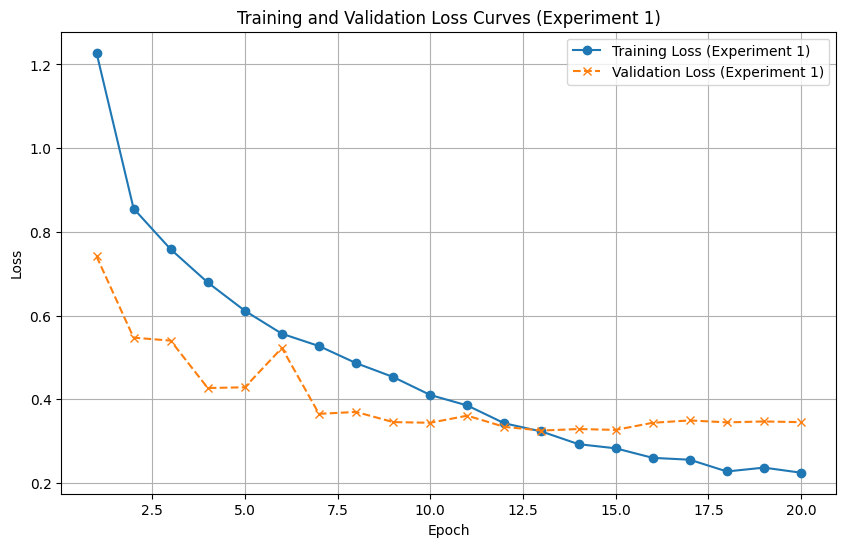

In [ ]:
import matplotlib.pyplot as plt

# Create a figure for the plot
plt.figure(figsize=(10, 6))

# Plot training loss
epochs_exp1 = range(1, len(train_losses_exp1) + 1)
plt.plot(epochs_exp1, train_losses_exp1, label='Training Loss (Experiment 1)', marker='o', linestyle='-')

# Plot validation loss
plt.plot(epochs_exp1, val_losses_exp1, label='Validation Loss (Experiment 1)', marker='x', linestyle='--')

# Add labels, title, legend, and grid
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves (Experiment 1)')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR

# Define Experiment 2: Same LR and scheduler as Exp1, but with a different BATCH_SIZE
experiment2_lr = experiment1_lr
experiment2_optimizer_type = experiment1_optimizer_type
experiment2_scheduler_config = experiment1_scheduler_config
experiment2_num_epochs = 20
experiment2_batch_size = 16 # Increased batch size

print(f"\n--- Running Experiment 2 ---")
print(f"LR: {experiment2_lr}, Optimizer: {experiment2_optimizer_type}, Scheduler: {experiment2_scheduler_config['type']}, Batch Size: {experiment2_batch_size}")

# Re-create dataloaders with the new batch size
train_loader_exp2, val_loader_exp2 = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=experiment2_batch_size,
    num_workers=NUM_WORKERS,
)

# Re-initialize the model to ensure a clean start for a new training run
model_exp2 = RetinaNetDetector(
    num_classes=num_classes,
    pretrained_backbone=True
)

# Train the model with new hyperparameters
model_exp2, train_losses_exp2, val_losses_exp2 = train_model(
    model=model_exp2,
    train_loader=train_loader_exp2,
    val_loader=val_loader_exp2,
    num_epochs=experiment2_num_epochs,
    checkpoint_dir='./checkpoints/exp2',
    lr=experiment2_lr,
    optimizer_type=experiment2_optimizer_type,
    scheduler_config=experiment2_scheduler_config
)

print(f"Captured train_losses for {len(train_losses_exp2)} epochs.")
print(f"Captured val_losses for {len(val_losses_exp2)} epochs.")


--- Running Experiment 2 ---
LR: 5e-05, Optimizer: AdamW, Scheduler: CosineAnnealingLR, Batch Size: 16
Training batches: 173
Validation batches: 50


The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please use 'weights_backbone' instead.
Arguments other than a weight enum or `None` for 'weights_backbone' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights_backbone=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights_backbone=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.


Using device: cuda

Epoch 1/20
--------------------------------------------------
Epoch: 1 | Batch: 0/173 | Loss: 1.8749 | Cls: 1.1482 Reg: 0.7266
Epoch: 1 | Batch: 20/173 | Loss: 1.5738 | Cls: 0.9456 Reg: 0.6282
Epoch: 1 | Batch: 40/173 | Loss: 1.4089 | Cls: 0.7976 Reg: 0.6113
Epoch: 1 | Batch: 60/173 | Loss: 1.2487 | Cls: 0.7025 Reg: 0.5463
Epoch: 1 | Batch: 80/173 | Loss: 1.2749 | Cls: 0.7586 Reg: 0.5163
Epoch: 1 | Batch: 100/173 | Loss: 1.2623 | Cls: 0.7446 Reg: 0.5177
Epoch: 1 | Batch: 120/173 | Loss: 1.2048 | Cls: 0.7025 Reg: 0.5023
Epoch: 1 | Batch: 140/173 | Loss: 1.0917 | Cls: 0.6412 Reg: 0.4505
Epoch: 1 | Batch: 160/173 | Loss: 1.1430 | Cls: 0.7045 Reg: 0.4385
Epoch 1 Summary:
  Train Loss: 1.2722
  Val Loss: 0.8657
  Learning Rate: 4.97e-05
Saved checkpoint: ./checkpoints/exp2/retinanet_epoch1.pth
Saved latest copy: ./checkpoints/exp2/retinanet_latest.pth

Epoch 2/20
--------------------------------------------------
Epoch: 2 | Batch: 0/173 | Loss: 0.9390 | Cls: 0.5212 Reg: 

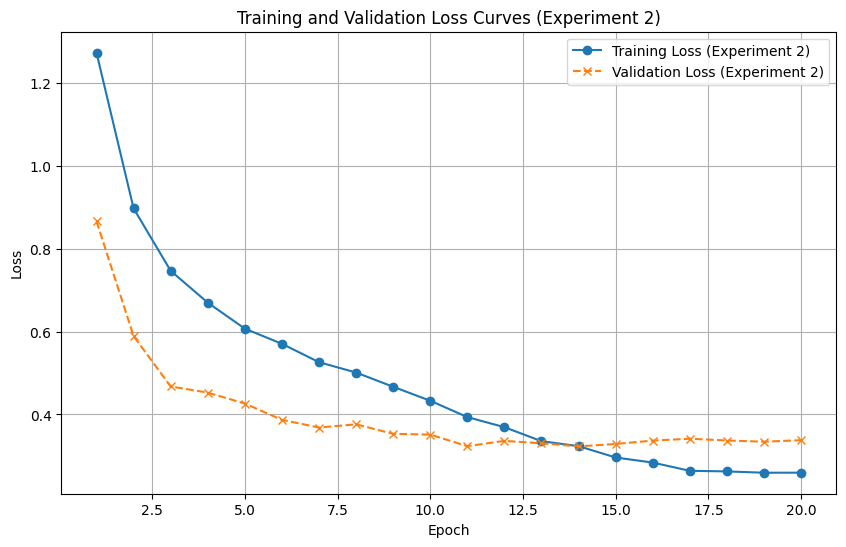

In [ ]:
import matplotlib.pyplot as plt

# Create a figure for the plot
plt.figure(figsize=(10, 6))

# Plot training loss
epochs_exp2 = range(1, len(train_losses_exp2) + 1)
plt.plot(epochs_exp2, train_losses_exp2, label='Training Loss (Experiment 2)', marker='o', linestyle='-')

# Plot validation loss
plt.plot(epochs_exp2, val_losses_exp2, label='Validation Loss (Experiment 2)', marker='x', linestyle='--')

# Add labels, title, legend, and grid
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves (Experiment 2)')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

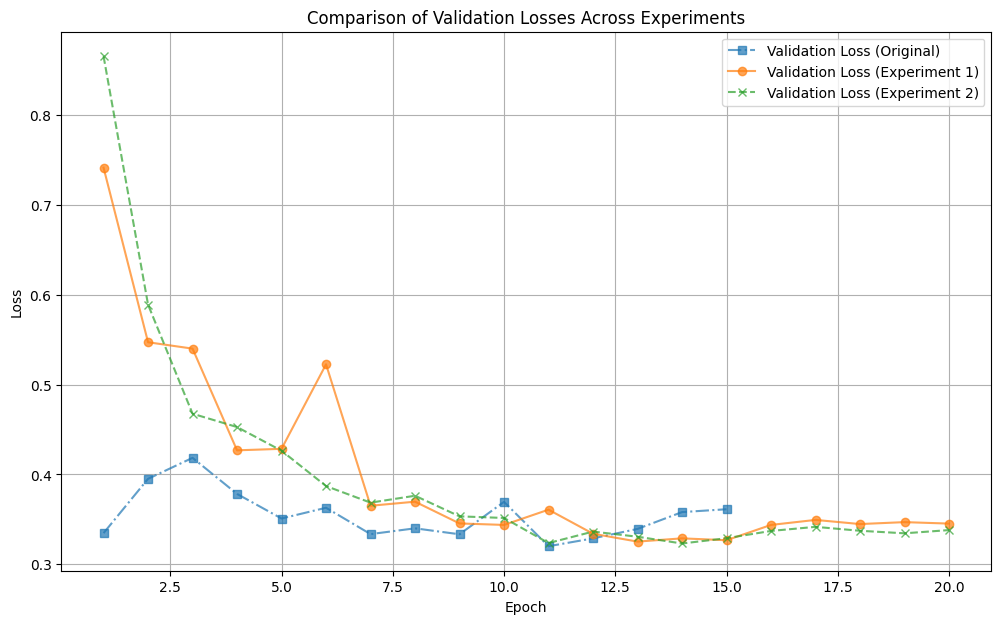

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Plot original validation loss
epochs_orig = range(1, len(val_losses) + 1)
plt.plot(epochs_orig, val_losses, label='Validation Loss (Original)', marker='s', linestyle='-.', alpha=0.7)

# Plot Experiment 1 validation loss
epochs_exp1 = range(1, len(val_losses_exp1) + 1)
plt.plot(epochs_exp1, val_losses_exp1, label='Validation Loss (Experiment 1)', marker='o', linestyle='-', alpha=0.7)

# Plot Experiment 2 validation loss
epochs_exp2 = range(1, len(val_losses_exp2) + 1)
plt.plot(epochs_exp2, val_losses_exp2, label='Validation Loss (Experiment 2)', marker='x', linestyle='--', alpha=0.7)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Comparison of Validation Losses Across Experiments')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# 1. Re-initialize the RetinaNetDetector model
model_exp1_eval = RetinaNetDetector(
    num_classes=num_classes,
    pretrained_backbone=True
)

# 2. Set up the device for model loading
device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"Using device for Experiment 1 model evaluation: {device}")

# Create dummy optimizer and scheduler objects for load_checkpoint
dummy_optimizer = optim.AdamW(model_exp1_eval.parameters(), lr=1e-4)
dummy_scheduler = StepLR(dummy_optimizer, step_size=10, gamma=0.1)

# 3. Define the path to the latest checkpoint for Experiment 1
latest_checkpoint_exp1_path = os.path.join('./checkpoints/exp1', 'retinanet_latest.pth')

# 4. Load the model's state dictionary from the specified checkpoint
# The return value (start_epoch) is not used here as we are only loading for evaluation
_ = load_checkpoint(
    latest_checkpoint_exp1_path,
    model_exp1_eval,
    optimizer=dummy_optimizer,
    scheduler=dummy_scheduler,
    device=device
)

print("Experiment 1 model weights loaded successfully from latest checkpoint.")

# 5. Call the evaluate_coco_map function
print("\nPerforming COCO mAP evaluation for Experiment 1 model...")
stats_exp1 = evaluate_coco_map(
    model_exp1_eval.model, # Pass the internal model for evaluation
    val_loader,
    val_dataset,
    device=device,
    score_threshold=0.01,
    print_diagnostics=True
)

# 6. Print the summary statistics
if stats_exp1 is None:
    print('No detections were produced for Experiment 1 (stats is None).')
else:
    print('\nSummary stats for Experiment 1:')
    for k, v in stats_exp1.items():
        if k in ('coco_eval', 'detections'):
            continue
        print(f"  {k}: {v:.4f}")

    # Additional checks for diagnostics
    dets_exp1 = stats_exp1.get('detections', [])
    print(f"Total detections written for Experiment 1: {len(dets_exp1)}")
    if len(dets_exp1) > 0:
        print('\nSample detections for Experiment 1 (first 5):')
        for d in dets_exp1[:5]:
            print(d)

    det_image_ids_exp1 = set(d['image_id'] for d in stats_exp1['detections'])
    gt_image_ids_exp1 = set(val_dataset.coco.getImgIds())
    overlap_exp1 = det_image_ids_exp1 & gt_image_ids_exp1
    print(f"\nUnique detection image_ids for Experiment 1: {len(det_image_ids_exp1)}")
    print(f"Unique GT image_ids in val_dataset: {len(gt_image_ids_exp1)}")
    print(f"Overlap between detection and GT image_ids for Experiment 1: {len(overlap_exp1)}")
    if len(overlap_exp1) == 0:
        print('WARNING: No overlap between detection image_ids and GT image_ids. This causes COCOeval to report zeros.')

The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please use 'weights_backbone' instead.
Arguments other than a weight enum or `None` for 'weights_backbone' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights_backbone=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights_backbone=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.


Using device for Experiment 1 model evaluation: cuda
Loading checkpoint ./checkpoints/exp1/retinanet_latest.pth to device cuda
Checkpoint loaded. Resuming from epoch 21
Experiment 1 model weights loaded successfully from latest checkpoint.

Performing COCO mAP evaluation for Experiment 1 model...
First-batch target image_id samples: [0, 1, 2, 3, 4, 5, 6, 7]
Diagnostic: unique detection image_ids: 794, GT image_ids: 796, overlap: 794
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.54s).
Accumulating evaluation results...
DONE (t=0.13s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.669
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.915
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.815
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.118
 Average Precision  (AP) @[ IoU

In [ ]:
print("Visualizing predictions for Experiment 1 model on validation image at index 0:")
visualize_prediction(val_dataset, index=0, model=model_exp1_eval)

print("\nVisualizing predictions for Experiment 1 model on validation image at index 1:")
visualize_prediction(val_dataset, index=1, model=model_exp1_eval)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# 1. Re-initialize the RetinaNetDetector model for Experiment 2
model_exp2_eval = RetinaNetDetector(
    num_classes=num_classes,
    pretrained_backbone=True
)

# 2. Set up the device for model loading
device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"Using device for Experiment 2 model evaluation: {device}")

# Create dummy optimizer and scheduler objects for load_checkpoint
dummy_optimizer = optim.AdamW(model_exp2_eval.parameters(), lr=1e-4)
dummy_scheduler = StepLR(dummy_optimizer, step_size=10, gamma=0.1)

# 3. Define the path to the latest checkpoint for Experiment 2
latest_checkpoint_exp2_path = os.path.join('./checkpoints/exp2', 'retinanet_latest.pth')

# 4. Load the model's state dictionary from the specified checkpoint
_ = load_checkpoint(
    latest_checkpoint_exp2_path,
    model_exp2_eval,
    optimizer=dummy_optimizer,
    scheduler=dummy_scheduler,
    device=device
)

print("Experiment 2 model weights loaded successfully from latest checkpoint.")

# 5. Call the evaluate_coco_map function for Experiment 2
print("\nPerforming COCO mAP evaluation for Experiment 2 model...")
stats_exp2 = evaluate_coco_map(
    model_exp2_eval.model,
    val_loader_exp2, # Use val_loader_exp2 which matches the batch size of Experiment 2
    val_dataset,
    device=device,
    score_threshold=0.01,
    print_diagnostics=True
)

# 6. Print the summary statistics for Experiment 2
if stats_exp2 is None:
    print('No detections were produced for Experiment 2 (stats is None).')
else:
    print('\nSummary stats for Experiment 2:')
    for k, v in stats_exp2.items():
        if k in ('coco_eval', 'detections'):
            continue
        print(f"  {k}: {v:.4f}")

    dets_exp2 = stats_exp2.get('detections', [])
    print(f"Total detections written for Experiment 2: {len(dets_exp2)}")
    if len(dets_exp2) > 0:
        print('\nSample detections for Experiment 2 (first 5):')
        for d in dets_exp2[:5]:
            print(d)

    det_image_ids_exp2 = set(d['image_id'] for d in stats_exp2['detections'])
    gt_image_ids_exp2 = set(val_dataset.coco.getImgIds())
    overlap_exp2 = det_image_ids_exp2 & gt_image_ids_exp2
    print(f"\nUnique detection image_ids for Experiment 2: {len(det_image_ids_exp2)}")
    print(f"Unique GT image_ids in val_dataset: {len(gt_image_ids_exp2)}")
    print(f"Overlap between detection and GT image_ids for Experiment 2: {len(overlap_exp2)}")
    if len(overlap_exp2) == 0:
        print('WARNING: No overlap between detection image_ids and GT image_ids. This causes COCOeval to report zeros.')

The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please use 'weights_backbone' instead.
Arguments other than a weight enum or `None` for 'weights_backbone' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights_backbone=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights_backbone=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.


Using device for Experiment 2 model evaluation: cuda
Loading checkpoint ./checkpoints/exp2/retinanet_latest.pth to device cuda
Checkpoint loaded. Resuming from epoch 21
Experiment 2 model weights loaded successfully from latest checkpoint.

Performing COCO mAP evaluation for Experiment 2 model...
First-batch target image_id samples: [0, 1, 2, 3, 4, 5, 6, 7]
Diagnostic: unique detection image_ids: 796, GT image_ids: 796, overlap: 796
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.65s).
Accumulating evaluation results...
DONE (t=0.16s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.656
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.918
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.795
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.131
 Average Precision  (AP) @[ IoU

In [ ]:
print("Visualizing predictions for Experiment 2 model on validation image at index 0:")
visualize_prediction(val_dataset, index=0, model=model_exp2_eval)

print("\nVisualizing predictions for Experiment 2 model on validation image at index 1:")
visualize_prediction(val_dataset, index=1, model=model_exp2_eval)

Output hidden; open in https://colab.research.google.com to view.